# Meridian Partner Commerce Health and Settlement Reconciliation

## Business analysis and KPI development

This notebook loads the processed Gold tables and creates business-ready KPI summaries for the fictional Meridian Market Group project.

The project uses entirely synthetic data and is unaffiliated with NEXT plc or any external partner.

## Notebook objective

This notebook will:

1. Load Gold analytical tables.
2. Calculate headline commercial and operational KPIs.
3. Create partner-level performance summaries.
4. Create dashboard-ready output files.
5. Prepare the metrics that will later be visualised in Power BI.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Project directory: {BASE_DIR}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project directory: /Users/tanayajadhav/Desktop/meridian_partner_commerce_health
Processed data directory: /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/data/processed
Output directory: /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs


In [4]:
# Load the Gold analytical tables

gold_order_metrics = pd.read_csv(
    PROCESSED_DIR / "gold_order_metrics.csv",
    low_memory=False
)

gold_partner_daily_metrics = pd.read_csv(
    PROCESSED_DIR / "gold_partner_daily_metrics.csv",
    low_memory=False
)

gold_listing_health = pd.read_csv(
    PROCESSED_DIR / "gold_listing_health.csv",
    low_memory=False
)

gold_settlement_reconciliation = pd.read_csv(
    PROCESSED_DIR / "gold_settlement_reconciliation.csv",
    low_memory=False
)

gold_exception_queue = pd.read_csv(
    PROCESSED_DIR / "gold_exception_queue.csv",
    low_memory=False
)

data_quality_summary = pd.read_csv(
    PROCESSED_DIR / "data_quality_summary.csv",
    low_memory=False
)

print("Gold tables loaded:")
print(
    f" - gold_order_metrics: "
    f"{len(gold_order_metrics):,} rows"
)
print(
    f" - gold_partner_daily_metrics: "
    f"{len(gold_partner_daily_metrics):,} rows"
)
print(
    f" - gold_listing_health: "
    f"{len(gold_listing_health):,} rows"
)
print(
    f" - gold_settlement_reconciliation: "
    f"{len(gold_settlement_reconciliation):,} rows"
)
print(
    f" - gold_exception_queue: "
    f"{len(gold_exception_queue):,} rows"
)

Gold tables loaded:
 - gold_order_metrics: 74,557 rows
 - gold_partner_daily_metrics: 6,942 rows
 - gold_listing_health: 67,003 rows
 - gold_settlement_reconciliation: 70,483 rows
 - gold_exception_queue: 162,235 rows


In [5]:
# Standardise types after loading the Gold CSV files

gold_order_metrics["order_timestamp"] = pd.to_datetime(
    gold_order_metrics["order_timestamp"],
    errors="coerce"
)

gold_order_metrics["order_date"] = pd.to_datetime(
    gold_order_metrics["order_date"],
    errors="coerce"
)

gold_partner_daily_metrics["order_date"] = pd.to_datetime(
    gold_partner_daily_metrics["order_date"],
    errors="coerce"
)

gold_listing_health["snapshot_date"] = pd.to_datetime(
    gold_listing_health["snapshot_date"],
    errors="coerce"
)

gold_listing_health[
    "latest_inventory_timestamp"
] = pd.to_datetime(
    gold_listing_health[
        "latest_inventory_timestamp"
    ],
    errors="coerce"
)

gold_settlement_reconciliation["order_date"] = pd.to_datetime(
    gold_settlement_reconciliation["order_date"],
    errors="coerce"
)

gold_exception_queue["event_date"] = pd.to_datetime(
    gold_exception_queue["event_date"],
    errors="coerce"
)

numeric_columns_by_table = {
    "gold_order_metrics": [
        "units",
        "gross_merchandise_value_gbp",
        "net_merchandise_value_gbp",
        "net_sales_before_returns_gbp",
        "shipping_amount_gbp",
        "tax_amount_gbp"
    ],
    "gold_listing_health": [
        "listing_available_units",
        "inventory_available_units",
        "content_completeness_pct",
        "listing_inventory_difference"
    ],
    "gold_settlement_reconciliation": [
        "expected_net_settlement_gbp",
        "reported_settlement_gbp",
        "settlement_variance_gbp",
        "absolute_variance_gbp"
    ],
    "gold_exception_queue": [
        "commercial_impact_gbp"
    ]
}

for column in numeric_columns_by_table["gold_order_metrics"]:
    gold_order_metrics[column] = pd.to_numeric(
        gold_order_metrics[column],
        errors="coerce"
    )

for column in numeric_columns_by_table["gold_listing_health"]:
    gold_listing_health[column] = pd.to_numeric(
        gold_listing_health[column],
        errors="coerce"
    )

for column in numeric_columns_by_table[
    "gold_settlement_reconciliation"
]:
    gold_settlement_reconciliation[column] = pd.to_numeric(
        gold_settlement_reconciliation[column],
        errors="coerce"
    )

for column in numeric_columns_by_table["gold_exception_queue"]:
    gold_exception_queue[column] = pd.to_numeric(
        gold_exception_queue[column],
        errors="coerce"
    )

print("Dates and numeric fields standardised.")

Dates and numeric fields standardised.


In [6]:
# Convert Boolean-style fields consistently

def to_boolean(series):
    return (
        series
        .astype("string")
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )


boolean_columns = [
    "cancelled_flag",
    "returned_or_refunded_flag",
    "missing_line_data_flag",
    "fx_missing_flag"
]

for column in boolean_columns:
    if column in gold_order_metrics.columns:
        gold_order_metrics[column] = to_boolean(
            gold_order_metrics[column]
        )

listing_boolean_columns = [
    "live_listing_flag",
    "inventory_missing_flag",
    "listing_inventory_disagreement_flag",
    "listing_offline_flag",
    "incomplete_content_flag",
    "inventory_stale_flag"
]

for column in listing_boolean_columns:
    if column in gold_listing_health.columns:
        gold_listing_health[column] = to_boolean(
            gold_listing_health[column]
        )

print("Boolean fields standardised.")

Boolean fields standardised.


In [7]:
# Calculate headline business KPIs

total_orders = (
    gold_order_metrics["order_id"]
    .nunique()
)

total_units = (
    gold_order_metrics["units"]
    .sum()
)

total_net_sales_gbp = (
    gold_order_metrics[
        "net_sales_before_returns_gbp"
    ]
    .sum()
)

average_order_value_gbp = (
    total_net_sales_gbp / total_orders
    if total_orders
    else 0
)

cancellation_rate = (
    gold_order_metrics["cancelled_flag"]
    .mean()
)

return_or_refund_rate = (
    gold_order_metrics[
        "returned_or_refunded_flag"
    ]
    .mean()
)

listing_count = len(gold_listing_health)

live_listing_rate = (
    gold_listing_health[
        "live_listing_flag"
    ]
    .mean()
)

listing_inventory_disagreement_rate = (
    gold_listing_health[
        "listing_inventory_disagreement_flag"
    ]
    .mean()
)

stale_inventory_rate = (
    gold_listing_health[
        "inventory_stale_flag"
    ]
    .mean()
)

incomplete_content_rate = (
    gold_listing_health[
        "incomplete_content_flag"
    ]
    .mean()
)

settlement_variance_total_gbp = (
    gold_settlement_reconciliation[
        "absolute_variance_gbp"
    ]
    .sum()
)

investigation_settlement_count = (
    gold_settlement_reconciliation[
        "reconciliation_status"
    ]
    .isin(
        [
            "investigate",
            "missing_reported_settlement"
        ]
    )
    .sum()
)

open_exception_count = (
    gold_exception_queue[
        "review_status"
    ]
    .eq("open")
    .sum()
)

high_severity_exception_count = (
    gold_exception_queue[
        "severity"
    ]
    .eq("high")
    .sum()
)

kpi_summary = pd.DataFrame([
    {
        "kpi_group": "Commercial",
        "kpi_name": "Total orders",
        "kpi_value": total_orders,
        "display_format": "integer"
    },
    {
        "kpi_group": "Commercial",
        "kpi_name": "Total units",
        "kpi_value": total_units,
        "display_format": "integer"
    },
    {
        "kpi_group": "Commercial",
        "kpi_name": "Net sales before returns",
        "kpi_value": round(
            total_net_sales_gbp,
            2
        ),
        "display_format": "gbp"
    },
    {
        "kpi_group": "Commercial",
        "kpi_name": "Average order value",
        "kpi_value": round(
            average_order_value_gbp,
            2
        ),
        "display_format": "gbp"
    },
    {
        "kpi_group": "Operations",
        "kpi_name": "Cancellation rate",
        "kpi_value": round(
            cancellation_rate,
            4
        ),
        "display_format": "percentage"
    },
    {
        "kpi_group": "Operations",
        "kpi_name": "Return or refund rate",
        "kpi_value": round(
            return_or_refund_rate,
            4
        ),
        "display_format": "percentage"
    },
    {
        "kpi_group": "Listing health",
        "kpi_name": "Live listing rate",
        "kpi_value": round(
            live_listing_rate,
            4
        ),
        "display_format": "percentage"
    },
    {
        "kpi_group": "Listing health",
        "kpi_name": "Listing-inventory disagreement rate",
        "kpi_value": round(
            listing_inventory_disagreement_rate,
            4
        ),
        "display_format": "percentage"
    },
    {
        "kpi_group": "Listing health",
        "kpi_name": "Stale inventory rate",
        "kpi_value": round(
            stale_inventory_rate,
            4
        ),
        "display_format": "percentage"
    },
    {
        "kpi_group": "Listing health",
        "kpi_name": "Incomplete content rate",
        "kpi_value": round(
            incomplete_content_rate,
            4
        ),
        "display_format": "percentage"
    },
    {
        "kpi_group": "Settlement",
        "kpi_name": "Total absolute settlement variance",
        "kpi_value": round(
            settlement_variance_total_gbp,
            2
        ),
        "display_format": "gbp"
    },
    {
        "kpi_group": "Settlement",
        "kpi_name": "Settlement investigations",
        "kpi_value": int(
            investigation_settlement_count
        ),
        "display_format": "integer"
    },
    {
        "kpi_group": "Data quality",
        "kpi_name": "Open exceptions",
        "kpi_value": int(
            open_exception_count
        ),
        "display_format": "integer"
    },
    {
        "kpi_group": "Data quality",
        "kpi_name": "High-severity exceptions",
        "kpi_value": int(
            high_severity_exception_count
        ),
        "display_format": "integer"
    }
])

display(kpi_summary)

,kpi_group,kpi_name,kpi_value,display_format
0,Commercial,Total orders,7.455700e+04,integer
1,Commercial,Total units,1.844370e+05,integer
2,Commercial,Net sales before returns,3.372581e+06,gbp
3,Commercial,Average order value,4.523000e+01,gbp
4,Operations,Cancellation rate,5.460000e-02,percentage
5,Operations,Return or refund rate,1.058000e-01,percentage
6,Listing health,Live listing rate,8.645000e-01,percentage
7,Listing health,Listing-inventory disagreement rate,8.609000e-01,percentage
8,Listing health,Stale inventory rate,4.763000e-01,percentage
9,Listing health,Incomplete content rate,3.840000e-02,percentage


In [8]:
# Create a partner-level commercial and operational summary

partner_summary = (
    gold_partner_daily_metrics
    .groupby(
        "partner_id",
        as_index=False
    )
    .agg(
        order_count=("order_count", "sum"),
        units=("units", "sum"),
        net_sales_gbp=(
            "net_sales_before_returns_gbp",
            "sum"
        ),
        cancelled_orders=(
            "cancelled_order_count",
            "sum"
        ),
        returned_or_refunded_orders=(
            "returned_or_refunded_order_count",
            "sum"
        ),
        days_with_activity=(
            "order_date",
            "nunique"
        )
    )
)

partner_summary["average_order_value_gbp"] = (
    partner_summary["net_sales_gbp"]
    / partner_summary["order_count"]
).round(2)

partner_summary["cancellation_rate"] = (
    partner_summary["cancelled_orders"]
    / partner_summary["order_count"]
).round(4)

partner_summary["return_or_refund_rate"] = (
    partner_summary[
        "returned_or_refunded_orders"
    ]
    / partner_summary["order_count"]
).round(4)

partner_summary = partner_summary.sort_values(
    "net_sales_gbp",
    ascending=False
)

display(partner_summary)

,partner_id,order_count,units,net_sales_gbp,cancelled_orders,returned_or_refunded_orders,days_with_activity,average_order_value_gbp,cancellation_rate,return_or_refund_rate
0,CH_A,32506,80263,1638549.86,1808,3463,546,50.41,0.0556,0.1065
1,CH_B,21979,54136,1013038.64,1218,2271,546,46.09,0.0554,0.1033
2,CH_C,13497,33771,616064.57,698,1419,487,45.64,0.0517,0.1051
3,CH_D,6575,16267,104928.03,350,736,395,15.96,0.0532,0.1119


In [9]:
# Save KPI and partner-summary outputs

kpi_summary_path = (
    OUTPUT_DIR / "kpi_summary.csv"
)

partner_summary_path = (
    OUTPUT_DIR / "partner_summary.csv"
)

kpi_summary.to_csv(
    kpi_summary_path,
    index=False
)

partner_summary.to_csv(
    partner_summary_path,
    index=False
)

print("outputs saved:")
print(f" - {kpi_summary_path}")
print(f" - {partner_summary_path}")

outputs saved:
 - /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/kpi_summary.csv
 - /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/partner_summary.csv


## Analyse Gold tables with SQL

DuckDB is used locally to demonstrate SQL analysis against the Gold analytical tables.

The SQL results will later become dashboard-ready outputs and will be adapted to Databricks SQL.

In [11]:
import duckdb

# Create an in-memory DuckDB connection
con = duckdb.connect(database=":memory:")

# Register the pandas dataframes as SQL tables
con.register(
    "gold_order_metrics",
    gold_order_metrics
)

con.register(
    "gold_partner_daily_metrics",
    gold_partner_daily_metrics
)

con.register(
    "gold_listing_health",
    gold_listing_health
)

con.register(
    "gold_settlement_reconciliation",
    gold_settlement_reconciliation
)

con.register(
    "gold_exception_queue",
    gold_exception_queue
)

print("Gold tables registered in DuckDB.")

Gold tables registered in DuckDB.


In [21]:
# Partner performance analysis using SQL

partner_performance_sql = """
SELECT
    partner_id,
    SUM(order_count) AS order_count,
    SUM(units) AS units,
    ROUND(
        SUM(net_sales_before_returns_gbp),
        2
    ) AS net_sales_gbp,
    SUM(cancelled_order_count) AS cancelled_orders,
    SUM(returned_or_refunded_order_count)
        AS returned_or_refunded_orders,
    ROUND(
        SUM(cancelled_order_count) * 1.0
        / NULLIF(SUM(order_count), 0),
        4
    ) AS cancellation_rate,
    ROUND(
        SUM(returned_or_refunded_order_count) * 1.0
        / NULLIF(SUM(order_count), 0),
        4
    ) AS return_or_refund_rate,
    ROUND(
        SUM(net_sales_before_returns_gbp)
        / NULLIF(SUM(order_count), 0),
        2
    ) AS average_order_value_gbp
FROM gold_partner_daily_metrics
GROUP BY
    partner_id
ORDER BY
    net_sales_gbp DESC
"""

sql_partner_performance = con.execute(
    partner_performance_sql
).df()

display(sql_partner_performance)

,partner_id,order_count,units,net_sales_gbp,cancelled_orders,returned_or_refunded_orders,cancellation_rate,return_or_refund_rate,average_order_value_gbp
0,CH_A,32506.0,80263.0,1638549.86,1808.0,3463.0,0.0556,0.1065,50.41
1,CH_B,21979.0,54136.0,1013038.64,1218.0,2271.0,0.0554,0.1033,46.09
2,CH_C,13497.0,33771.0,616064.57,698.0,1419.0,0.0517,0.1051,45.64
3,CH_D,6575.0,16267.0,104928.03,350.0,736.0,0.0532,0.1119,15.96


In [25]:
# Add GBP inventory-value-at-risk to the listing-health table

# Load the processed FX table
silver_fx_rate = pd.read_csv(
    PROCESSED_DIR / "silver_fx_rate.csv",
    low_memory=False
)

silver_fx_rate["rate_date"] = pd.to_datetime(
    silver_fx_rate["rate_date"],
    errors="coerce"
)

silver_fx_rate["rate_to_gbp"] = pd.to_numeric(
    silver_fx_rate["rate_to_gbp"],
    errors="coerce"
)

# Use valid FX records only
valid_fx = silver_fx_rate[
    silver_fx_rate["record_status"].eq("valid")
].copy()

# Use the latest valid rate for each currency
latest_fx_rates = (
    valid_fx
    .sort_values("rate_date")
    .drop_duplicates(
        subset=["from_currency"],
        keep="last"
    )
    .set_index("from_currency")[
        "rate_to_gbp"
    ]
    .to_dict()
)

# Make sure listing monetary and inventory fields are numeric
gold_listing_health["price_local"] = pd.to_numeric(
    gold_listing_health["price_local"],
    errors="coerce"
)

gold_listing_health[
    "inventory_available_units"
] = pd.to_numeric(
    gold_listing_health[
        "inventory_available_units"
    ],
    errors="coerce"
)

# Create an explicit definition of an inventory-risk listing
gold_listing_health["listing_exception_flag"] = (
    gold_listing_health["listing_offline_flag"]
    | gold_listing_health[
        "listing_inventory_disagreement_flag"
    ]
    | gold_listing_health["inventory_stale_flag"]
)

gold_listing_health["currency_rate_to_gbp"] = (
    gold_listing_health["currency_code"]
    .map(latest_fx_rates)
    .fillna(1.0)
)

gold_listing_health[
    "estimated_inventory_value_at_risk_gbp"
] = np.where(
    gold_listing_health["listing_exception_flag"],
    (
        gold_listing_health[
            "inventory_available_units"
        ]
        .fillna(0)
        .clip(lower=0)
        * gold_listing_health[
            "price_local"
        ].fillna(0)
        * gold_listing_health[
            "currency_rate_to_gbp"
        ]
    ),
    0
).round(2)

print(
    "Inventory-risk metric created."
)

display(
    gold_listing_health[
        [
            "partner_id",
            "country_code",
            "internal_sku",
            "listing_exception_flag",
            "inventory_available_units",
            "price_local",
            "currency_rate_to_gbp",
            "estimated_inventory_value_at_risk_gbp"
        ]
    ].head()
)

Inventory-risk metric created.


,partner_id,country_code,internal_sku,listing_exception_flag,inventory_available_units,price_local,currency_rate_to_gbp,estimated_inventory_value_at_risk_gbp
0,CH_A,BE,SKU_000003,True,50.0,7.96,0.826632,329.00
1,CH_A,DE,SKU_000003,True,40.0,12.44,0.826632,411.33
2,CH_A,DK,SKU_000003,True,0.0,96.27,0.118629,0.00
3,CH_A,ES,SKU_000003,True,78.0,13.22,0.826632,852.39
4,CH_A,FR,SKU_000003,True,32.0,8.23,0.826632,217.70


In [29]:
# Force-create and register the listing-risk metric

# Confirm the source dataframe exists
print(
    "Pandas dataframe exists:",
    "gold_listing_health" in globals()
)

# Load FX data directly from the processed folder
silver_fx_rate = pd.read_csv(
    PROCESSED_DIR / "silver_fx_rate.csv",
    low_memory=False
)

silver_fx_rate["rate_date"] = pd.to_datetime(
    silver_fx_rate["rate_date"],
    errors="coerce"
)

silver_fx_rate["rate_to_gbp"] = pd.to_numeric(
    silver_fx_rate["rate_to_gbp"],
    errors="coerce"
)

valid_fx = silver_fx_rate[
    silver_fx_rate["record_status"].astype(str).eq("valid")
].copy()

latest_fx_rates = (
    valid_fx
    .sort_values("rate_date")
    .drop_duplicates(
        subset=["from_currency"],
        keep="last"
    )
    .set_index("from_currency")[
        "rate_to_gbp"
    ]
    .to_dict()
)

# Convert required listing fields to numeric
gold_listing_health["price_local"] = pd.to_numeric(
    gold_listing_health["price_local"],
    errors="coerce"
)

gold_listing_health[
    "inventory_available_units"
] = pd.to_numeric(
    gold_listing_health[
        "inventory_available_units"
    ],
    errors="coerce"
)

# Make sure the relevant flag columns are Boolean
for column in [
    "listing_offline_flag",
    "listing_inventory_disagreement_flag",
    "inventory_stale_flag"
]:
    gold_listing_health[column] = (
        gold_listing_health[column]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("true")
    )

# Define which listings have an operational exception
gold_listing_health["listing_exception_flag"] = (
    gold_listing_health["listing_offline_flag"]
    | gold_listing_health[
        "listing_inventory_disagreement_flag"
    ]
    | gold_listing_health["inventory_stale_flag"]
)

# Add synthetic FX conversion
gold_listing_health["currency_rate_to_gbp"] = (
    gold_listing_health["currency_code"]
    .map(latest_fx_rates)
    .fillna(1.0)
)

# Calculate the missing metric
gold_listing_health[
    "estimated_inventory_value_at_risk_gbp"
] = np.where(
    gold_listing_health["listing_exception_flag"],
    (
        gold_listing_health[
            "inventory_available_units"
        ]
        .fillna(0)
        .clip(lower=0)
        * gold_listing_health[
            "price_local"
        ].fillna(0)
        * gold_listing_health[
            "currency_rate_to_gbp"
        ]
    ),
    0
).round(2)

print(
    "Pandas column exists:",
    "estimated_inventory_value_at_risk_gbp"
    in gold_listing_health.columns
)

# Remove the old DuckDB registration if it exists
try:
    con.unregister("gold_listing_health")
except Exception:
    pass

# Register the updated dataframe
con.register(
    "gold_listing_health",
    gold_listing_health
)

# Verify the DuckDB schema directly
duckdb_schema = con.execute(
    "DESCRIBE gold_listing_health"
).df()

print("\nDuckDB columns matching the required metric:")
display(
    duckdb_schema[
        duckdb_schema["column_name"]
        == "estimated_inventory_value_at_risk_gbp"
    ]
)

Pandas dataframe exists: True
Pandas column exists: True

DuckDB columns matching the required metric:


,column_name,column_type,null,key,default,extra
25,estimated_inventory_value_at_risk_gbp,DOUBLE,YES,None,None,None


In [31]:
# Listing-health analysis using SQL

listing_health_sql = """
SELECT
    partner_id,
    country_code,
    COUNT(*) AS listing_count,
    SUM(
        CASE
            WHEN live_listing_flag = TRUE
            THEN 1
            ELSE 0
        END
    ) AS live_listing_count,
    ROUND(
        SUM(
            CASE
                WHEN live_listing_flag = TRUE
                THEN 1
                ELSE 0
            END
        ) * 1.0 / NULLIF(COUNT(*), 0),
        4
    ) AS live_listing_rate,
    SUM(
        CASE
            WHEN listing_inventory_disagreement_flag = TRUE
            THEN 1
            ELSE 0
        END
    ) AS inventory_disagreement_count,
    SUM(
        CASE
            WHEN inventory_stale_flag = TRUE
            THEN 1
            ELSE 0
        END
    ) AS stale_inventory_count,
    SUM(
        CASE
            WHEN incomplete_content_flag = TRUE
            THEN 1
            ELSE 0
        END
    ) AS incomplete_content_count,
    ROUND(
        SUM(
            COALESCE(
                estimated_inventory_value_at_risk_gbp,
                0
            )
        ),
        2
    ) AS estimated_inventory_value_at_risk_gbp
FROM gold_listing_health
GROUP BY
    partner_id,
    country_code
ORDER BY
    estimated_inventory_value_at_risk_gbp DESC
"""

sql_listing_health = con.execute(
    listing_health_sql
).df()

display(sql_listing_health.head(20))

,partner_id,country_code,listing_count,live_listing_count,live_listing_rate,inventory_disagreement_count,stale_inventory_count,incomplete_content_count,estimated_inventory_value_at_risk_gbp
0,CH_A,GB,2234,1918.0,0.8585,2213.0,1078.0,74.0,3742620.81
1,CH_B,GB,1947,1692.0,0.8690,1930.0,895.0,73.0,3244408.62
2,CH_A,DE,2234,1933.0,0.8653,2181.0,1054.0,94.0,2422934.98
3,CH_C,GB,1489,1277.0,0.8576,1477.0,697.0,67.0,2396246.91
4,CH_A,FR,2234,1930.0,0.8639,2160.0,1031.0,100.0,2333878.02
5,CH_B,DE,1947,1713.0,0.8798,1912.0,940.0,68.0,2139434.22
6,CH_B,FR,1946,1690.0,0.8684,1873.0,965.0,74.0,2010339.96
7,CH_A,NL,2222,1901.0,0.8555,2004.0,1041.0,92.0,1936209.93
8,CH_D,GB,1188,1040.0,0.8754,1180.0,573.0,35.0,1930768.71
9,CH_A,ES,2215,1901.0,0.8582,1943.0,1052.0,94.0,1785571.13


In [33]:
# Settlement reconciliation analysis using SQL

settlement_reconciliation_sql = """
SELECT
    partner_id,
    reconciliation_status,
    COUNT(*) AS order_count,
    ROUND(
        SUM(expected_net_settlement_gbp),
        2
    ) AS expected_settlement_gbp,
    ROUND(
        SUM(reported_settlement_gbp),
        2
    ) AS reported_settlement_gbp,
    ROUND(
        SUM(settlement_variance_gbp),
        2
    ) AS settlement_variance_gbp,
    ROUND(
        SUM(absolute_variance_gbp),
        2
    ) AS absolute_variance_gbp
FROM gold_settlement_reconciliation
GROUP BY
    partner_id,
    reconciliation_status
ORDER BY
    absolute_variance_gbp DESC
"""

sql_settlement_reconciliation = con.execute(
    settlement_reconciliation_sql
).df()

display(sql_settlement_reconciliation)

,partner_id,reconciliation_status,order_count,expected_settlement_gbp,reported_settlement_gbp,settlement_variance_gbp,absolute_variance_gbp
0,CH_A,missing_reported_settlement,27239,735705.72,0.0,-735705.72,820891.86
1,CH_B,missing_reported_settlement,18448,438197.22,0.0,-438197.22,495230.98
2,CH_C,missing_reported_settlement,11208,287112.18,0.0,-287112.18,314965.20
3,CH_D,missing_reported_settlement,1821,36615.61,0.0,-36615.61,42210.35
4,CH_A,not_yet_settled,533,16941.46,0.0,-16941.46,16941.46
5,CH_B,not_yet_settled,347,10118.52,0.0,-10118.52,10118.52
6,CH_C,not_yet_settled,238,7339.92,0.0,-7339.92,7339.92
7,CH_D,minor_variance,3185,5728.07,0.0,-5728.07,7284.63
8,CH_A,minor_variance,2121,-719.63,0.0,719.63,5758.17
9,CH_B,minor_variance,1455,-683.54,0.0,683.54,3961.66


In [35]:
# Commercial exception prioritisation using SQL

exception_priority_sql = """
SELECT
    issue_type,
    severity,
    COUNT(*) AS exception_count,
    ROUND(
        SUM(commercial_impact_gbp),
        2
    ) AS total_commercial_impact_gbp,
    ROUND(
        AVG(commercial_impact_gbp),
        2
    ) AS average_commercial_impact_gbp,
    ROUND(
        MAX(commercial_impact_gbp),
        2
    ) AS maximum_commercial_impact_gbp
FROM gold_exception_queue
WHERE review_status = 'open'
GROUP BY
    issue_type,
    severity
ORDER BY
    CASE severity
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'low' THEN 3
        ELSE 4
    END,
    total_commercial_impact_gbp DESC
"""

sql_exception_priority = con.execute(
    exception_priority_sql
).df()

display(sql_exception_priority)

,issue_type,severity,exception_count,total_commercial_impact_gbp,average_commercial_impact_gbp,maximum_commercial_impact_gbp
0,listing_inventory_disagreement,high,5013,18068617.38,3604.35,18526.84
1,stale_inventory,high,2448,8779754.27,3586.50,16773.22
2,listing_offline_or_paused,high,455,1609239.94,3536.79,12440.95
3,incomplete_listing_content,high,197,691713.62,3511.24,12229.30
4,listing_inventory_disagreement,medium,19690,26277362.52,1334.55,2290.60
5,stale_inventory,medium,9744,12925075.08,1326.47,2290.60
6,listing_offline_or_paused,medium,2218,2916383.77,1314.87,2289.28
7,incomplete_listing_content,medium,771,1041927.75,1351.40,2286.63
8,partner_metric_anomaly,medium,23,23961.55,1041.81,1451.09
9,listing_inventory_disagreement,low,32979,14310482.49,433.93,829.60


In [37]:
# Save SQL-generated analytical outputs

sql_partner_performance_path = (
    OUTPUT_DIR / "sql_partner_performance.csv"
)

sql_listing_health_path = (
    OUTPUT_DIR / "sql_listing_health.csv"
)

sql_settlement_reconciliation_path = (
    OUTPUT_DIR / "sql_settlement_reconciliation.csv"
)

sql_exception_priority_path = (
    OUTPUT_DIR / "sql_exception_priority.csv"
)

sql_partner_performance.to_csv(
    sql_partner_performance_path,
    index=False
)

sql_listing_health.to_csv(
    sql_listing_health_path,
    index=False
)

sql_settlement_reconciliation.to_csv(
    sql_settlement_reconciliation_path,
    index=False
)

sql_exception_priority.to_csv(
    sql_exception_priority_path,
    index=False
)

print("SQL outputs saved:")
print(f" - {sql_partner_performance_path}")
print(f" - {sql_listing_health_path}")
print(f" - {sql_settlement_reconciliation_path}")
print(f" - {sql_exception_priority_path}")

SQL outputs saved:
 - /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/sql_partner_performance.csv
 - /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/sql_listing_health.csv
 - /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/sql_settlement_reconciliation.csv
 - /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/sql_exception_priority.csv


## Create business-analysis charts

These charts are exploratory outputs used to understand the major commercial, operational, listing-health, settlement, and exception patterns before building the Power BI dashboard.

In [40]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

CHART_DPI = 160

print("Visualisation libraries loaded.")

Visualisation libraries loaded.


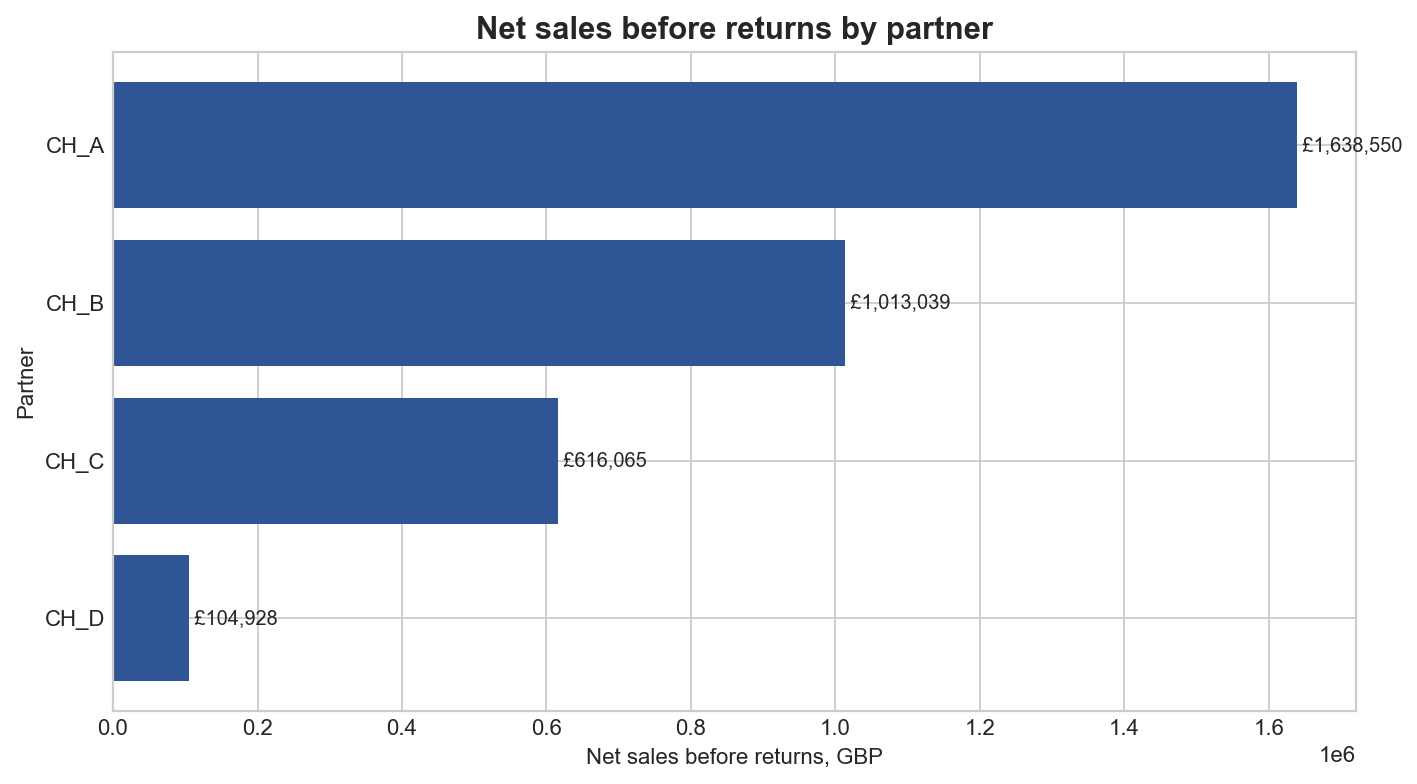

Saved: /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/chart_partner_sales.png


In [42]:
# Chart 1: Net sales by partner

partner_sales_chart = (
    sql_partner_performance
    .sort_values(
        "net_sales_gbp",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5),
    dpi=CHART_DPI
)

ax.barh(
    partner_sales_chart["partner_id"],
    partner_sales_chart["net_sales_gbp"],
    color="#2F5597"
)

ax.set_title(
    "Net sales before returns by partner",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Net sales before returns, GBP")
ax.set_ylabel("Partner")

for index, value in enumerate(
    partner_sales_chart["net_sales_gbp"]
):
    ax.text(
        value,
        index,
        f" £{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

partner_sales_chart_path = (
    OUTPUT_DIR / "chart_partner_sales.png"
)

plt.savefig(
    partner_sales_chart_path,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {partner_sales_chart_path}")

In [44]:
# Prepare listing-health metrics by partner

listing_health_chart = (
    gold_listing_health
    .groupby("partner_id", as_index=False)
    .agg(
        listing_count=(
            "internal_sku",
            "count"
        ),
        live_listing_rate=(
            "live_listing_flag",
            "mean"
        ),
        inventory_disagreement_rate=(
            "listing_inventory_disagreement_flag",
            "mean"
        ),
        stale_inventory_rate=(
            "inventory_stale_flag",
            "mean"
        ),
        incomplete_content_rate=(
            "incomplete_content_flag",
            "mean"
        ),
        inventory_value_at_risk_gbp=(
            "estimated_inventory_value_at_risk_gbp",
            "sum"
        )
    )
)

for column in [
    "live_listing_rate",
    "inventory_disagreement_rate",
    "stale_inventory_rate",
    "incomplete_content_rate"
]:
    listing_health_chart[column] = (
        listing_health_chart[column] * 100
    ).round(2)

display(listing_health_chart)

,partner_id,listing_count,live_listing_rate,inventory_disagreement_rate,stale_inventory_rate,incomplete_content_rate,inventory_value_at_risk_gbp
0,CH_A,21848,85.94,86.24,47.48,3.82,19924006.99
1,CH_B,19044,86.89,86.96,47.56,3.74,17630805.02
2,CH_C,14561,86.40,85.96,47.59,4.09,12845776.60
3,CH_D,11550,86.76,84.54,48.1,3.74,9870567.47


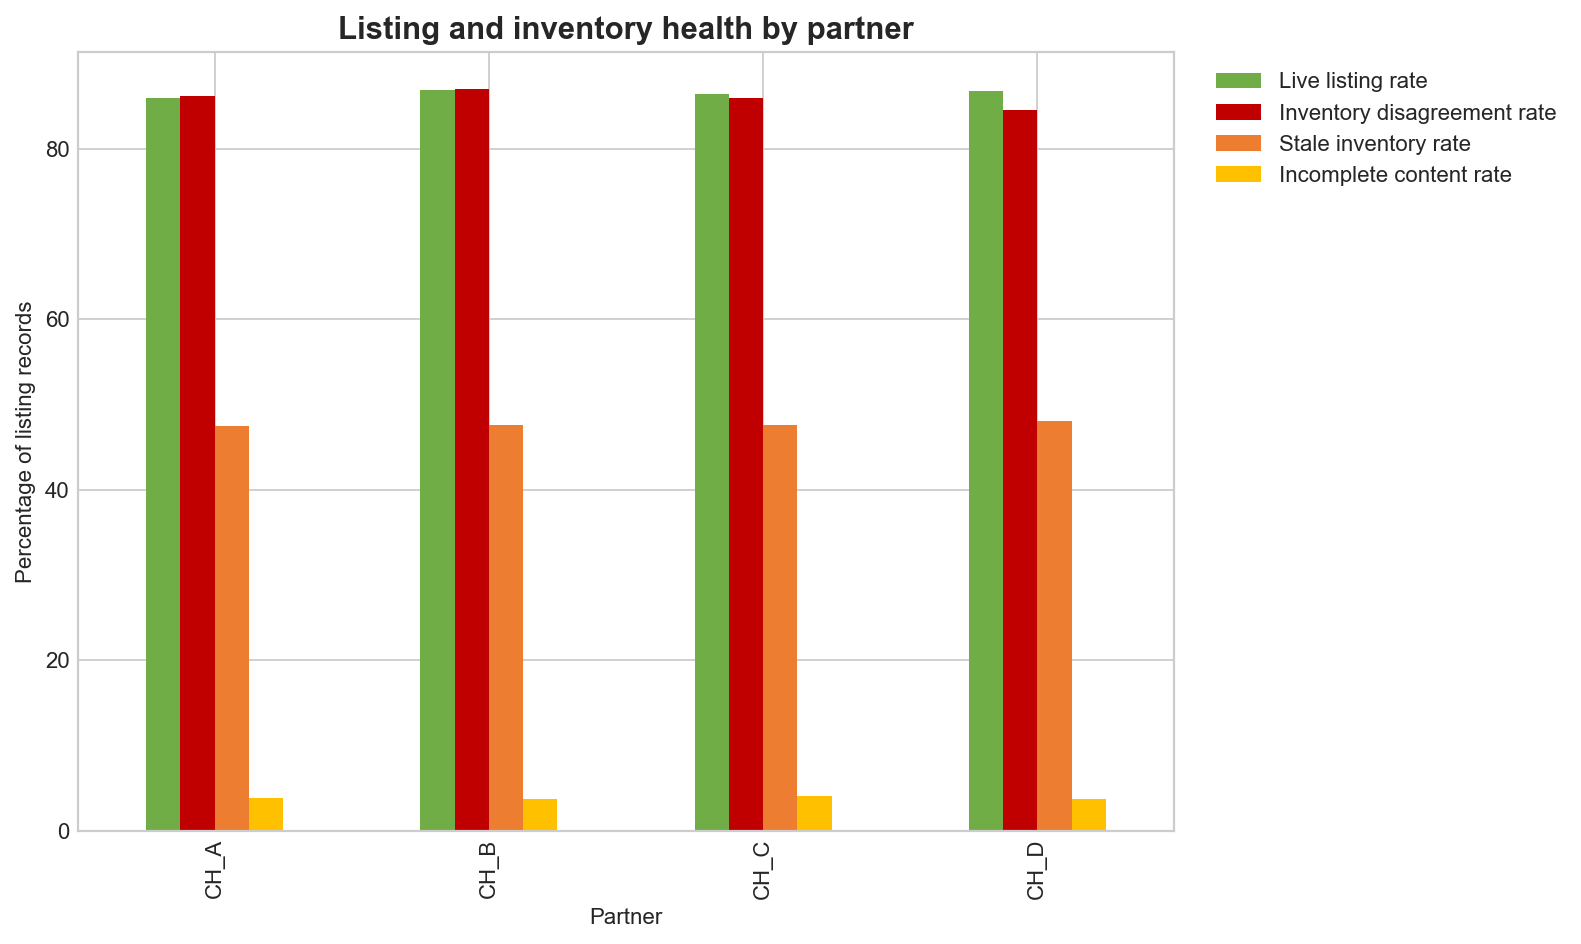

Saved: /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/chart_listing_health.png


In [46]:
# Chart 2: Listing-health rates by partner

listing_chart_plot = (
    listing_health_chart
    .set_index("partner_id")[
        [
            "live_listing_rate",
            "inventory_disagreement_rate",
            "stale_inventory_rate",
            "incomplete_content_rate"
        ]
    ]
)

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=CHART_DPI
)

listing_chart_plot.plot(
    kind="bar",
    ax=ax,
    color=[
        "#70AD47",
        "#C00000",
        "#ED7D31",
        "#FFC000"
    ]
)

ax.set_title(
    "Listing and inventory health by partner",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Partner")
ax.set_ylabel("Percentage of listing records")
ax.legend(
    [
        "Live listing rate",
        "Inventory disagreement rate",
        "Stale inventory rate",
        "Incomplete content rate"
    ],
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

ax.set_ylim(bottom=0)

plt.tight_layout()

listing_health_chart_path = (
    OUTPUT_DIR / "chart_listing_health.png"
)

plt.savefig(
    listing_health_chart_path,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {listing_health_chart_path}")

In [48]:
# Prepare settlement variance by partner

settlement_chart = (
    gold_settlement_reconciliation
    .groupby("partner_id", as_index=False)
    .agg(
        absolute_variance_gbp=(
            "absolute_variance_gbp",
            "sum"
        ),
        settlement_variance_gbp=(
            "settlement_variance_gbp",
            "sum"
        ),
        investigated_orders=(
            "reconciliation_status",
            lambda values: values.isin(
                [
                    "investigate",
                    "missing_reported_settlement"
                ]
            ).sum()
        )
    )
    .sort_values(
        "absolute_variance_gbp",
        ascending=True
    )
)

display(settlement_chart)

,partner_id,absolute_variance_gbp,settlement_variance_gbp,investigated_orders
3,CH_D,51410.13,-43912.11,1821
2,CH_C,325187.72,-294202.18,11208
1,CH_B,509560.44,-447637.90,18448
0,CH_A,843987.78,-751926.06,27239


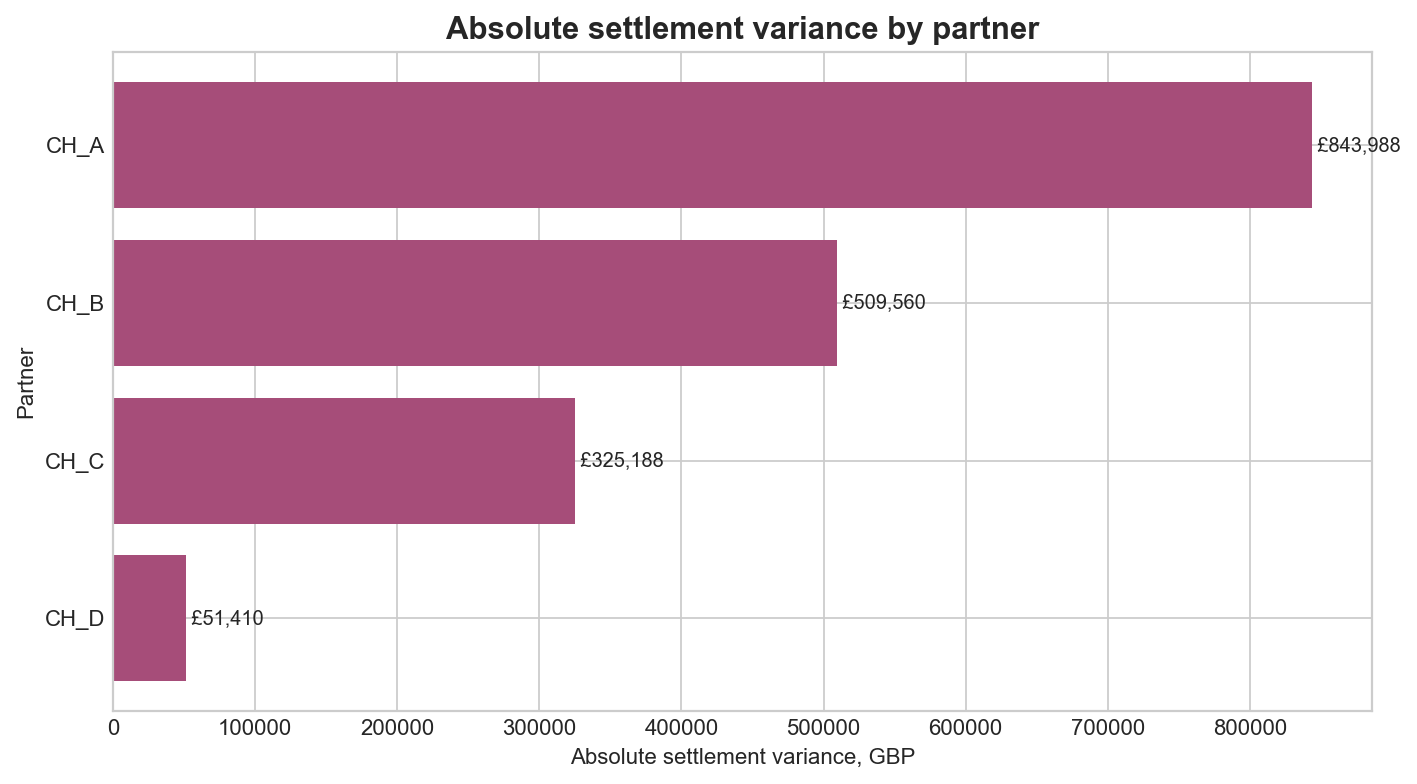

Saved: /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/chart_settlement_variance.png


In [50]:
# Chart 3: Absolute settlement variance by partner

fig, ax = plt.subplots(
    figsize=(9, 5),
    dpi=CHART_DPI
)

ax.barh(
    settlement_chart["partner_id"],
    settlement_chart["absolute_variance_gbp"],
    color="#A64D79"
)

ax.set_title(
    "Absolute settlement variance by partner",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Absolute settlement variance, GBP")
ax.set_ylabel("Partner")

for index, value in enumerate(
    settlement_chart["absolute_variance_gbp"]
):
    ax.text(
        value,
        index,
        f" £{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

settlement_chart_path = (
    OUTPUT_DIR / "chart_settlement_variance.png"
)

plt.savefig(
    settlement_chart_path,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {settlement_chart_path}")

In [52]:
# Prepare commercial exception impact by issue type

exception_impact_chart = (
    gold_exception_queue
    .groupby("issue_type", as_index=False)
    .agg(
        exception_count=(
            "exception_id",
            "nunique"
        ),
        total_commercial_impact_gbp=(
            "commercial_impact_gbp",
            "sum"
        ),
        high_severity_count=(
            "severity",
            lambda values: (values == "high").sum()
        )
    )
    .sort_values(
        "total_commercial_impact_gbp",
        ascending=True
    )
)

display(exception_impact_chart)

,issue_type,exception_count,total_commercial_impact_gbp,high_severity_count
3,partner_metric_anomaly,2271,444065.67,0
4,settlement_variance,58716,1673298.39,0
0,incomplete_listing_content,2574,2368151.40,197
2,listing_offline_or_paused,9077,6641857.80,455
5,stale_inventory,31915,29443061.54,2448
1,listing_inventory_disagreement,57682,58656462.39,5013


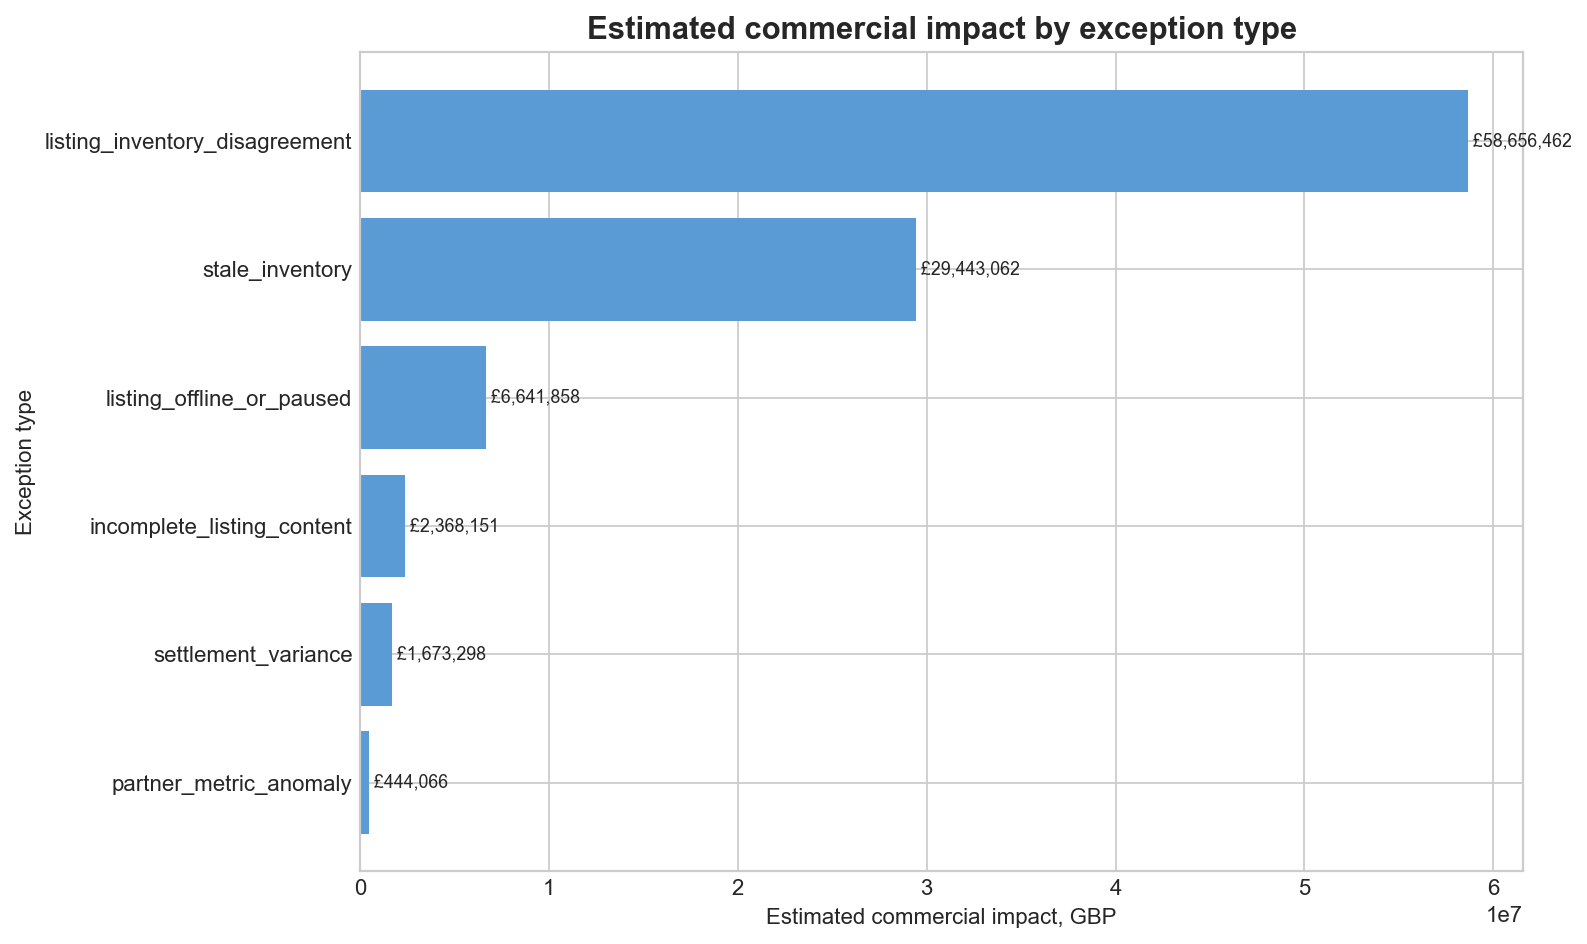

Saved: /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/chart_exception_impact.png


In [54]:
# Chart 4: Commercial impact by exception type

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=CHART_DPI
)

ax.barh(
    exception_impact_chart["issue_type"],
    exception_impact_chart[
        "total_commercial_impact_gbp"
    ],
    color="#5B9BD5"
)

ax.set_title(
    "Estimated commercial impact by exception type",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Estimated commercial impact, GBP")
ax.set_ylabel("Exception type")

for index, value in enumerate(
    exception_impact_chart[
        "total_commercial_impact_gbp"
    ]
):
    ax.text(
        value,
        index,
        f" £{value:,.0f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()

exception_impact_chart_path = (
    OUTPUT_DIR / "chart_exception_impact.png"
)

plt.savefig(
    exception_impact_chart_path,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {exception_impact_chart_path}")

In [56]:
# Save the supporting chart data tables

listing_health_chart.to_csv(
    OUTPUT_DIR / "listing_health_chart_data.csv",
    index=False
)

settlement_chart.to_csv(
    OUTPUT_DIR / "settlement_chart_data.csv",
    index=False
)

exception_impact_chart.to_csv(
    OUTPUT_DIR / "exception_impact_chart_data.csv",
    index=False
)

print("Chart data tables saved to the outputs folder.")

Chart data tables saved to the outputs folder.


## Prepare the Power BI star-schema dataset

This step creates fact tables, dimension tables, relationship documentation, and a measure catalogue for the Power BI dashboard.

The model is designed to support partner, country, product, date, listing-health, settlement, and exception analysis.

In [59]:
# Load reference data for Power BI dimensions

dim_partner = pd.read_csv(
    BASE_DIR
    / "data"
    / "reference"
    / "partner_ref.csv"
)

dim_country = pd.read_csv(
    BASE_DIR
    / "data"
    / "reference"
    / "country_ref.csv"
)

dim_product = pd.read_csv(
    BASE_DIR
    / "data"
    / "reference"
    / "product_ref.csv"
)

dim_partner["active_from"] = pd.to_datetime(
    dim_partner["active_from"],
    errors="coerce"
)

dim_partner["active_to"] = pd.to_datetime(
    dim_partner["active_to"],
    errors="coerce"
)

dim_product["active_from"] = pd.to_datetime(
    dim_product["active_from"],
    errors="coerce"
)

dim_product["active_to"] = pd.to_datetime(
    dim_product["active_to"],
    errors="coerce"
)

print("Dimension tables loaded:")
print(
    f" - dim_partner: {len(dim_partner):,} rows"
)
print(
    f" - dim_country: {len(dim_country):,} rows"
)
print(
    f" - dim_product: {len(dim_product):,} rows"
)

Dimension tables loaded:
 - dim_partner: 4 rows
 - dim_country: 10 rows
 - dim_product: 3,000 rows


In [61]:
# Create a reusable date dimension

date_start = pd.Timestamp("2025-01-01")
date_end = pd.Timestamp("2026-12-31")

date_values = pd.date_range(
    start=date_start,
    end=date_end,
    freq="D"
)

dim_date = pd.DataFrame({
    "date": date_values
})

dim_date["date_key"] = (
    dim_date["date"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

dim_date["year"] = (
    dim_date["date"].dt.year
)

dim_date["quarter"] = (
    "Q"
    + dim_date["date"].dt.quarter.astype(str)
)

dim_date["month_number"] = (
    dim_date["date"].dt.month
)

dim_date["month_name"] = (
    dim_date["date"].dt.month_name()
)

dim_date["year_month"] = (
    dim_date["date"].dt.strftime("%Y-%m")
)

dim_date["week_number"] = (
    dim_date["date"].dt.isocalendar().week.astype(int)
)

dim_date["day_of_week_number"] = (
    dim_date["date"].dt.dayofweek + 1
)

dim_date["day_of_week_name"] = (
    dim_date["date"].dt.day_name()
)

dim_date["is_weekend"] = (
    dim_date["date"].dt.dayofweek >= 5
)

display(dim_date.head())

,date,date_key,year,quarter,month_number,month_name,year_month,week_number,day_of_week_number,day_of_week_name,is_weekend
0,2025-01-01,20250101,2025,Q1,1,January,2025-01,1,3,Wednesday,False
1,2025-01-02,20250102,2025,Q1,1,January,2025-01,1,4,Thursday,False
2,2025-01-03,20250103,2025,Q1,1,January,2025-01,1,5,Friday,False
3,2025-01-04,20250104,2025,Q1,1,January,2025-01,1,6,Saturday,True
4,2025-01-05,20250105,2025,Q1,1,January,2025-01,1,7,Sunday,True


In [63]:
# Create Power BI fact-table copies

fact_order_metrics = gold_order_metrics.copy()

fact_partner_daily_metrics = (
    gold_partner_daily_metrics.copy()
)

fact_listing_health = (
    gold_listing_health.copy()
)

fact_settlement_reconciliation = (
    gold_settlement_reconciliation.copy()
)

# Use the prioritised queue for the main dashboard fact table
gold_prioritised_exception_queue = pd.read_csv(
    PROCESSED_DIR
    / "gold_prioritised_exception_queue.csv",
    low_memory=False
)

fact_exception_queue = (
    gold_prioritised_exception_queue.copy()
)

# Add date keys to fact tables where appropriate
fact_order_metrics["order_date"] = pd.to_datetime(
    fact_order_metrics["order_date"],
    errors="coerce"
)

fact_order_metrics["order_date_key"] = (
    fact_order_metrics["order_date"]
    .dt.strftime("%Y%m%d")
    .astype("Int64")
)

fact_partner_daily_metrics["order_date"] = pd.to_datetime(
    fact_partner_daily_metrics["order_date"],
    errors="coerce"
)

fact_partner_daily_metrics["order_date_key"] = (
    fact_partner_daily_metrics["order_date"]
    .dt.strftime("%Y%m%d")
    .astype("Int64")
)

fact_listing_health["snapshot_date"] = pd.to_datetime(
    fact_listing_health["snapshot_date"],
    errors="coerce"
)

fact_listing_health["snapshot_date_key"] = (
    fact_listing_health["snapshot_date"]
    .dt.strftime("%Y%m%d")
    .astype("Int64")
)

fact_settlement_reconciliation["order_date"] = (
    pd.to_datetime(
        fact_settlement_reconciliation[
            "order_date"
        ],
        errors="coerce"
    )
)

fact_settlement_reconciliation["order_date_key"] = (
    fact_settlement_reconciliation["order_date"]
    .dt.strftime("%Y%m%d")
    .astype("Int64")
)

fact_exception_queue["event_date"] = pd.to_datetime(
    fact_exception_queue["event_date"],
    errors="coerce"
)

fact_exception_queue["event_date_key"] = (
    fact_exception_queue["event_date"]
    .dt.strftime("%Y%m%d")
    .astype("Int64")
)

print("Power BI fact tables prepared.")

Power BI fact tables prepared.


In [65]:
# Document the intended Power BI relationships

powerbi_relationships = pd.DataFrame([
    {
        "from_table": "fact_order_metrics",
        "from_column": "partner_id",
        "to_table": "dim_partner",
        "to_column": "partner_id",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_order_metrics",
        "from_column": "country_code",
        "to_table": "dim_country",
        "to_column": "country_code",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_order_metrics",
        "from_column": "order_date_key",
        "to_table": "dim_date",
        "to_column": "date_key",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_partner_daily_metrics",
        "from_column": "partner_id",
        "to_table": "dim_partner",
        "to_column": "partner_id",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_partner_daily_metrics",
        "from_column": "country_code",
        "to_table": "dim_country",
        "to_column": "country_code",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_partner_daily_metrics",
        "from_column": "order_date_key",
        "to_table": "dim_date",
        "to_column": "date_key",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_listing_health",
        "from_column": "partner_id",
        "to_table": "dim_partner",
        "to_column": "partner_id",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_listing_health",
        "from_column": "country_code",
        "to_table": "dim_country",
        "to_column": "country_code",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_listing_health",
        "from_column": "internal_sku",
        "to_table": "dim_product",
        "to_column": "internal_sku",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_listing_health",
        "from_column": "snapshot_date_key",
        "to_table": "dim_date",
        "to_column": "date_key",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_settlement_reconciliation",
        "from_column": "partner_id",
        "to_table": "dim_partner",
        "to_column": "partner_id",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_settlement_reconciliation",
        "from_column": "country_code",
        "to_table": "dim_country",
        "to_column": "country_code",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_settlement_reconciliation",
        "from_column": "order_date_key",
        "to_table": "dim_date",
        "to_column": "date_key",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_exception_queue",
        "from_column": "partner_id",
        "to_table": "dim_partner",
        "to_column": "partner_id",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_exception_queue",
        "from_column": "country_code",
        "to_table": "dim_country",
        "to_column": "country_code",
        "cardinality": "many-to-one"
    },
    {
        "from_table": "fact_exception_queue",
        "from_column": "event_date_key",
        "to_table": "dim_date",
        "to_column": "date_key",
        "cardinality": "many-to-one"
    }
])

display(powerbi_relationships)

,from_table,from_column,to_table,to_column,cardinality
0,fact_order_metrics,partner_id,dim_partner,partner_id,many-to-one
1,fact_order_metrics,country_code,dim_country,country_code,many-to-one
2,fact_order_metrics,order_date_key,dim_date,date_key,many-to-one
3,fact_partner_daily_metrics,partner_id,dim_partner,partner_id,many-to-one
4,fact_partner_daily_metrics,country_code,dim_country,country_code,many-to-one
5,fact_partner_daily_metrics,order_date_key,dim_date,date_key,many-to-one
6,fact_listing_health,partner_id,dim_partner,partner_id,many-to-one
7,fact_listing_health,country_code,dim_country,country_code,many-to-one
8,fact_listing_health,internal_sku,dim_product,internal_sku,many-to-one
9,fact_listing_health,snapshot_date_key,dim_date,date_key,many-to-one


In [67]:
# Document recommended Power BI measures

powerbi_measure_catalog = pd.DataFrame([
    {
        "measure_name": "Net Sales GBP",
        "definition": "SUM(fact_order_metrics[net_sales_before_returns_gbp])",
        "format": "Currency",
        "business_purpose": "Measures sales before returns and refunds."
    },
    {
        "measure_name": "Orders",
        "definition": "DISTINCTCOUNT(fact_order_metrics[order_id])",
        "format": "Whole number",
        "business_purpose": "Counts customer orders."
    },
    {
        "measure_name": "Units",
        "definition": "SUM(fact_order_metrics[units])",
        "format": "Whole number",
        "business_purpose": "Measures products sold."
    },
    {
        "measure_name": "Average Order Value",
        "definition": "[Net Sales GBP] / [Orders]",
        "format": "Currency",
        "business_purpose": "Compares basket value across partners and countries."
    },
    {
        "measure_name": "Cancellation Rate",
        "definition": "DIVIDE(SUM(fact_order_metrics[cancelled_flag]), [Orders])",
        "format": "Percentage",
        "business_purpose": "Monitors order cancellation performance."
    },
    {
        "measure_name": "Live Listing Rate",
        "definition": "DIVIDE(SUM(fact_listing_health[live_listing_flag]), COUNTROWS(fact_listing_health))",
        "format": "Percentage",
        "business_purpose": "Measures product availability on partner channels."
    },
    {
        "measure_name": "Inventory Disagreement Rate",
        "definition": "DIVIDE(SUM(fact_listing_health[listing_inventory_disagreement_flag]), COUNTROWS(fact_listing_health))",
        "format": "Percentage",
        "business_purpose": "Highlights possible stock-synchronisation issues."
    },
    {
        "measure_name": "Settlement Variance GBP",
        "definition": "SUM(fact_settlement_reconciliation[settlement_variance_gbp])",
        "format": "Currency",
        "business_purpose": "Measures the difference between expected and reported settlement."
    },
    {
        "measure_name": "Open Exception Count",
        "definition": "CALCULATE(COUNTROWS(fact_exception_queue), fact_exception_queue[review_status] = \"open\")",
        "format": "Whole number",
        "business_purpose": "Shows the current review workload."
    },
    {
        "measure_name": "Exception Impact GBP",
        "definition": "SUM(fact_exception_queue[commercial_impact_gbp])",
        "format": "Currency",
        "business_purpose": "Prioritises issues by estimated commercial impact."
    }
])

display(powerbi_measure_catalog)

,measure_name,definition,format,business_purpose
0,Net Sales GBP,SUM(fact_order_metrics[net_sales_before_return...,Currency,Measures sales before returns and refunds.
1,Orders,DISTINCTCOUNT(fact_order_metrics[order_id]),Whole number,Counts customer orders.
2,Units,SUM(fact_order_metrics[units]),Whole number,Measures products sold.
3,Average Order Value,[Net Sales GBP] / [Orders],Currency,Compares basket value across partners and coun...
4,Cancellation Rate,DIVIDE(SUM(fact_order_metrics[cancelled_flag])...,Percentage,Monitors order cancellation performance.
5,Live Listing Rate,DIVIDE(SUM(fact_listing_health[live_listing_fl...,Percentage,Measures product availability on partner chann...
6,Inventory Disagreement Rate,DIVIDE(SUM(fact_listing_health[listing_invento...,Percentage,Highlights possible stock-synchronisation issues.
7,Settlement Variance GBP,SUM(fact_settlement_reconciliation[settlement_...,Currency,Measures the difference between expected and r...
8,Open Exception Count,"CALCULATE(COUNTROWS(fact_exception_queue), fac...",Whole number,Shows the current review workload.
9,Exception Impact GBP,SUM(fact_exception_queue[commercial_impact_gbp]),Currency,Prioritises issues by estimated commercial imp...


In [71]:
# Recreate the Power BI output directory

from pathlib import Path

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"
POWERBI_DIR = OUTPUT_DIR / "powerbi"

POWERBI_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Power BI output folder is ready: {POWERBI_DIR}")

Power BI output folder is ready: /Users/tanayajadhav/Desktop/meridian_partner_commerce_health/outputs/powerbi


In [73]:
# Export fact tables, dimensions, relationships, and measures

powerbi_exports = {
    "fact_order_metrics": fact_order_metrics,
    "fact_partner_daily_metrics": fact_partner_daily_metrics,
    "fact_listing_health": fact_listing_health,
    "fact_settlement_reconciliation": fact_settlement_reconciliation,
    "fact_exception_queue": fact_exception_queue,
    "dim_partner": dim_partner,
    "dim_country": dim_country,
    "dim_product": dim_product,
    "dim_date": dim_date,
    "powerbi_relationships": powerbi_relationships,
    "powerbi_measure_catalog": powerbi_measure_catalog
}

for table_name, table in powerbi_exports.items():
    output_path = POWERBI_DIR / f"{table_name}.csv"

    table.to_csv(
        output_path,
        index=False
    )

    print(
        f"{table_name}: "
        f"{len(table):,} rows saved"
    )

fact_order_metrics: 74,557 rows saved
fact_partner_daily_metrics: 6,942 rows saved
fact_listing_health: 67,003 rows saved
fact_settlement_reconciliation: 70,483 rows saved
fact_exception_queue: 10,000 rows saved
dim_partner: 4 rows saved
dim_country: 10 rows saved
dim_product: 3,000 rows saved
dim_date: 730 rows saved
powerbi_relationships: 16 rows saved
powerbi_measure_catalog: 10 rows saved


In [75]:
# Validate the Power BI export folder

powerbi_files = sorted(
    POWERBI_DIR.glob("*.csv")
)

print(
    "Power BI export files:",
    len(powerbi_files)
)

for path in powerbi_files:
    print(
        f" - {path.name}: "
        f"{path.stat().st_size / 1024**2:.2f} MB"
    )

Power BI export files: 11
 - dim_country.csv: 0.00 MB
 - dim_date.csv: 0.04 MB
 - dim_partner.csv: 0.00 MB
 - dim_product.csv: 0.28 MB
 - fact_exception_queue.csv: 2.50 MB
 - fact_listing_health.csv: 11.31 MB
 - fact_order_metrics.csv: 13.52 MB
 - fact_partner_daily_metrics.csv: 0.53 MB
 - fact_settlement_reconciliation.csv: 10.21 MB
 - powerbi_measure_catalog.csv: 0.00 MB
 - powerbi_relationships.csv: 0.00 MB
